In [1]:
import pandas as pd
df = pd.read_excel("freshcart_subscription_decision_tree_dataset.xlsx")

In [2]:
df.head()

,Customer_ID,Age_Group,City_Type,Membership_Type,Months_As_Customer,Monthly_Orders,Avg_Order_Value,Late_Deliveries_Last_3M,Support_Tickets_Last_3M,Discount_Usage_Rate,App_Sessions_Per_Month,Delivery_Rating,Competitor_Offer_Seen,Payment_Issues_Last_3M,Household_Size,Preferred_Category,Last_Login_Days,Renewed_Membership
0,FC10001,35-44,Urban,Basic,16,7,27.99,0,1.0,0.42,31,4.1,No,0,2,Household Essentials,2.0,No
1,FC10002,18-24,Suburban,Plus,12,4,64.85,1,0.0,0.29,19,4.4,No,0,2,Pet Supplies,0.0,No
2,FC10003,45-54,Suburban,Premium,2,5,85.03,1,0.0,0.29,21,4.2,Yes,0,1,Prepared Meals,9.0,No
3,FC10004,35-44,Urban,Plus,20,7,70.37,2,0.0,0.00,24,4.3,Yes,0,3,Fresh Produce,9.0,No
4,FC10005,45-54,Urban,Plus,1,8,44.87,1,0.0,0.45,29,4.6,No,0,3,Pet Supplies,19.0,Yes


In [3]:
df.shape

(360, 18)

In [4]:
df.columns

Index(['Customer_ID', 'Age_Group', 'City_Type', 'Membership_Type',
       'Months_As_Customer', 'Monthly_Orders', 'Avg_Order_Value',
       'Late_Deliveries_Last_3M', 'Support_Tickets_Last_3M',
       'Discount_Usage_Rate', 'App_Sessions_Per_Month', 'Delivery_Rating',
       'Competitor_Offer_Seen', 'Payment_Issues_Last_3M', 'Household_Size',
       'Preferred_Category', 'Last_Login_Days', 'Renewed_Membership'],
      dtype='object')

In [5]:
df.dtypes

Customer_ID                 object
Age_Group                   object
City_Type                   object
Membership_Type             object
Months_As_Customer           int64
Monthly_Orders               int64
Avg_Order_Value            float64
Late_Deliveries_Last_3M      int64
Support_Tickets_Last_3M    float64
Discount_Usage_Rate        float64
App_Sessions_Per_Month       int64
Delivery_Rating            float64
Competitor_Offer_Seen       object
Payment_Issues_Last_3M       int64
Household_Size               int64
Preferred_Category          object
Last_Login_Days            float64
Renewed_Membership          object
dtype: object

In [6]:
null_values = df.isnull().sum()
print("Sum of null values for each column:\n", null_values)

Sum of null values for each column:
 Customer_ID                0
Age_Group                  0
City_Type                  0
Membership_Type            0
Months_As_Customer         0
Monthly_Orders             0
Avg_Order_Value            1
Late_Deliveries_Last_3M    0
Support_Tickets_Last_3M    1
Discount_Usage_Rate        1
App_Sessions_Per_Month     0
Delivery_Rating            1
Competitor_Offer_Seen      0
Payment_Issues_Last_3M     0
Household_Size             0
Preferred_Category         1
Last_Login_Days            1
Renewed_Membership         0
dtype: int64


In [7]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [8]:
# Select numerical features for clustering
numerical_features = [
    'Months_As_Customer',
    'Monthly_Orders',
    'Avg_Order_Value',
    'App_Sessions_Per_Month',
    'Delivery_Rating',
    'Discount_Usage_Rate',
    'Late_Deliveries_Last_3M',
    'Support_Tickets_Last_3M',
    'Last_Login_Days',
    'Household_Size',
    'Payment_Issues_Last_3M'
]

In [9]:
# Fill numerical missing values with the median
for col in numerical_features:
    df[col] = df[col].fillna(df[col].median())

In [10]:
null_values = df.isnull().sum()
print("Sum of null values for each column:\n", null_values)

Sum of null values for each column:
 Customer_ID                0
Age_Group                  0
City_Type                  0
Membership_Type            0
Months_As_Customer         0
Monthly_Orders             0
Avg_Order_Value            0
Late_Deliveries_Last_3M    0
Support_Tickets_Last_3M    0
Discount_Usage_Rate        0
App_Sessions_Per_Month     0
Delivery_Rating            0
Competitor_Offer_Seen      0
Payment_Issues_Last_3M     0
Household_Size             0
Preferred_Category         1
Last_Login_Days            0
Renewed_Membership         0
dtype: int64


In [11]:
Cat_features = df.select_dtypes(include=['object']).columns
Cat_features

Index(['Customer_ID', 'Age_Group', 'City_Type', 'Membership_Type',
       'Competitor_Offer_Seen', 'Preferred_Category', 'Renewed_Membership'],
      dtype='object')

In [12]:
#Fill categorical missing values with the mode
for col in Cat_features:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
null_values = df.isnull().sum()
print("Sum of null values for each column:\n", null_values)

Sum of null values for each column:
 Customer_ID                0
Age_Group                  0
City_Type                  0
Membership_Type            0
Months_As_Customer         0
Monthly_Orders             0
Avg_Order_Value            0
Late_Deliveries_Last_3M    0
Support_Tickets_Last_3M    0
Discount_Usage_Rate        0
App_Sessions_Per_Month     0
Delivery_Rating            0
Competitor_Offer_Seen      0
Payment_Issues_Last_3M     0
Household_Size             0
Preferred_Category         0
Last_Login_Days            0
Renewed_Membership         0
dtype: int64


In [14]:
# Features for clustering
X = df[numerical_features]

In [15]:
# Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier viewing
import pandas as pd

X_scaled = pd.DataFrame(
    X_scaled,
    columns=numerical_features
)

X_scaled.head()

,Months_As_Customer,Monthly_Orders,Avg_Order_Value,App_Sessions_Per_Month,Delivery_Rating,Discount_Usage_Rate,Late_Deliveries_Last_3M,Support_Tickets_Last_3M,Last_Login_Days,Household_Size,Payment_Issues_Last_3M
0,0.480159,0.920723,-1.499141,1.190867,0.232948,0.830380,-0.880236,0.832580,-0.867688,-0.281222,-0.267261
1,-0.106792,-0.275885,0.558227,-0.009167,0.826306,0.100992,0.243470,-0.681202,-1.051326,-0.281222,-0.267261
2,-1.574170,0.122985,1.684589,0.190839,0.430734,0.100992,0.243470,-0.681202,-0.224956,-1.153981,-0.267261
3,1.067110,0.920723,0.866330,0.490847,0.628520,-1.526103,1.367175,-0.681202,-0.224956,0.591536,-0.267261
4,-1.720908,1.319592,-0.556971,0.990861,1.221878,0.998700,0.243470,-0.681202,0.693232,0.591536,-0.267261


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

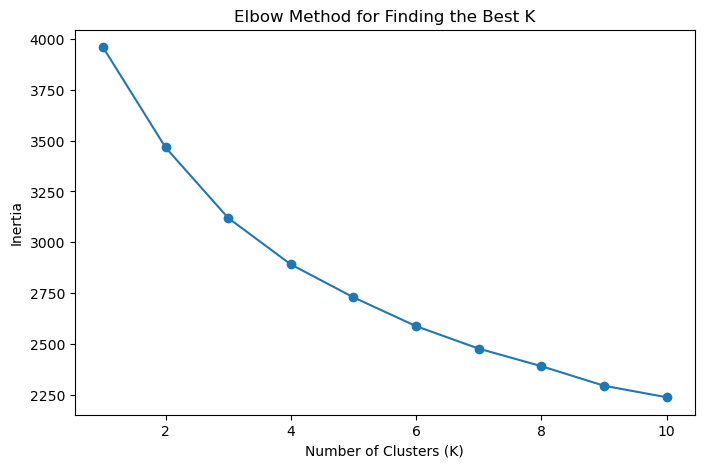

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create an empty list to store inertia values
inertia = []

# Test different values of K
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Finding the Best K")
plt.show()

In [17]:
# Display inertia values for each K

elbow_results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia
})

elbow_results

,K,Inertia
0,1,3960.000000
1,2,3466.328613
2,3,3119.161111
3,4,2890.603971
4,5,2728.466817
5,6,2586.563860
6,7,2475.871669
7,8,2389.632902
8,9,2293.190574
9,10,2236.641142


In [ ]:
## Selecting the Number of Clusters

The Elbow Method was used to determine the optimal number of clusters for K-Means clustering. The method evaluates the Within-Cluster Sum of Squares (WCSS), also known as inertia, for different values of K.

Based on the elbow plot, the decrease in inertia becomes noticeably less significant after approximately **4 clusters**. From K=1 to K=4 the inertia drops sharply, but from K=5 onward the improvement becomes smaller and more gradual. This indicates that adding more clusters beyond this point provides only limited improvement in cluster compactness.

Therefore, **K = 4** was selected as the optimal number of clusters because it provides a reasonable balance between cluster quality and model complexity.

## Training the Final K-Means Model

A K-Means clustering model was trained using **4 clusters** and the scaled numerical features:

- Months_As_Customer
- Monthly_Orders
- Avg_Order_Value
- App_Sessions_Per_Month
- Delivery_Rating
- Discount_Usage_Rate
- Late_Deliveries_Last_3M
- Support_Tickets_Last_3M
- Last_Login_Days
- Household_Size
- Payment_Issues_Last_3M

The resulting cluster labels were added back to the dataset to enable further analysis and interpretation of the identified customer groups.

In [18]:

# Create the K-means model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Train the model and assign cluster labels
cluster_labels = kmeans.fit_predict(X_scaled)

# Display the first 10 cluster labels
cluster_labels[:10]


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


array([2, 2, 2, 2, 2, 0, 0, 2, 0, 1], dtype=int32)

In [19]:
pd.Series(cluster_labels).value_counts().sort_index()

0    134
1     81
2    121
3     24
Name: count, dtype: int64

In [20]:
# Create a copy of the cleaned dataset
df_clustered = df.copy()

# Add cluster labels to the dataset
df_clustered["Cluster"] = cluster_labels

# Display the first five rows
df_clustered.head()

,Customer_ID,Age_Group,City_Type,Membership_Type,Months_As_Customer,Monthly_Orders,Avg_Order_Value,Late_Deliveries_Last_3M,Support_Tickets_Last_3M,Discount_Usage_Rate,App_Sessions_Per_Month,Delivery_Rating,Competitor_Offer_Seen,Payment_Issues_Last_3M,Household_Size,Preferred_Category,Last_Login_Days,Renewed_Membership,Cluster
0,FC10001,35-44,Urban,Basic,16,7,27.99,0,1.0,0.42,31,4.1,No,0,2,Household Essentials,2.0,No,2
1,FC10002,18-24,Suburban,Plus,12,4,64.85,1,0.0,0.29,19,4.4,No,0,2,Pet Supplies,0.0,No,2
2,FC10003,45-54,Suburban,Premium,2,5,85.03,1,0.0,0.29,21,4.2,Yes,0,1,Prepared Meals,9.0,No,2
3,FC10004,35-44,Urban,Plus,20,7,70.37,2,0.0,0.00,24,4.3,Yes,0,3,Fresh Produce,9.0,No,2
4,FC10005,45-54,Urban,Plus,1,8,44.87,1,0.0,0.45,29,4.6,No,0,3,Pet Supplies,19.0,Yes,2


In [21]:
# Check how many customers are in each cluster

df_clustered["Cluster"].value_counts().sort_index()

Cluster
0    134
1     81
2    121
3     24
Name: count, dtype: int64

In [22]:
cluster_summary = df_clustered.groupby('Cluster')[
    numerical_features
].mean().round(2)

cluster_summary

,Months_As_Customer,Monthly_Orders,Avg_Order_Value,App_Sessions_Per_Month,Delivery_Rating,Discount_Usage_Rate,Late_Deliveries_Last_3M,Support_Tickets_Last_3M,Last_Login_Days,Household_Size,Payment_Issues_Last_3M
Cluster,,,,,,,,,,,
0,13.26,2.70,46.73,11.03,4.01,0.34,0.60,0.23,11.99,2.28,0.0
1,12.84,5.26,58.84,22.21,3.55,0.23,1.56,1.11,9.32,2.33,0.0
2,11.98,6.64,61.70,26.26,4.25,0.23,0.43,0.21,11.93,2.27,0.0
3,13.17,4.08,52.19,17.42,3.98,0.30,1.00,0.67,13.21,2.79,1.0


In [ ]:
## Cluster Analysis

### How many customer/user segments did you find?

Using the Elbow Method, K = 4 was selected as the optimal number of clusters. The K-Means model therefore identified **4 distinct customer segments**.

The cluster sizes were:

| Cluster | Number of Customers |
|---------|---------------------|
| 0 | 134 |
| 1 | 81 |
| 2 | 121 |
| 3 | 24 |

### What are the main characteristics of each segment?

#### Cluster 0 – Passive Low-Spenders
- Low monthly orders (2.70 per month)
- Lowest average order value ($46.73)
- Low app sessions (11.03 per month)
- Very few late deliveries (0.60) and support tickets (0.23)
- Moderate last login recency (11.99 days)

This cluster represents customers who rarely engage with the platform and spend little. They simply do not use the service enough to see value in renewing.

#### Cluster 1 – Active At-Risk Customers
- Moderate monthly orders (5.26 per month)
- Moderate average order value ($58.84)
- High app sessions (22.21 per month)
- **Highest late deliveries (1.56)** and most support tickets (1.11)
- Lowest delivery rating (3.55)

These customers actively use the service but are experiencing the worst service quality. Poor delivery performance and high complaint volume are driving their churn despite strong engagement.

#### Cluster 2 – High-Value Loyalists
- **Highest monthly orders (6.64 per month)**
- **Highest average order value ($61.70)**
- **Most app sessions (26.26 per month)**
- Fewest late deliveries (0.43) and lowest support tickets (0.21)
- Best delivery rating (4.25)

This cluster contains the most engaged and satisfied customers. They use the platform heavily, spend the most, and experience the best service quality.

#### Cluster 3 – Payment-Friction Customers
- Moderate monthly orders (4.08 per month)
- Moderate average order value ($52.19)
- Moderate app sessions (17.42 per month)
- **Payment issues present (1.0)** — the only cluster with payment problems
- Moderate late deliveries (1.00) and support tickets (0.67)

This small but distinct group has payment issues that create a logistical barrier to renewal. They are moderately engaged but face financial friction.

### How are the segments different from each other?

The clusters differ primarily in two dimensions: **engagement and spending** (orders, app sessions, order value) and **service experience** (late deliveries, delivery ratings, support tickets). Cluster 2 scores highest on engagement and service quality. Cluster 1 is highly engaged but has the worst service experience. Cluster 0 is low on both. Cluster 3 is unique in having payment-related issues, which no other cluster shows.

### Which segment may be the most valuable for the business? Why?

**Cluster 2 (High-Value Loyalists)** is the most valuable segment.

Reasons:
- Highest average order value ($61.70) and most frequent ordering (6.64 per month)
- Most active on the app (26.26 sessions per month)
- Best delivery ratings and fewest service problems
- Highest renewal rate among all clusters (~47%)

These customers generate the most revenue and are most likely to remain subscribers. Maintaining excellent service for this segment should be a top priority.

### Which segment may need more marketing attention? Why?

**Cluster 1 (Active At-Risk Customers)** requires the most urgent attention.

Reasons:
- High app engagement shows they actively want to use the service
- Highest number of late deliveries (1.56) and support tickets (1.11)
- Lowest delivery rating (3.55) indicates significant dissatisfaction
- Only ~15% renewal rate despite high engagement

FreshCart Plus could focus on service recovery outreach, proactive delivery improvement, and targeted offers to retain these customers, since their engagement level shows they are willing to stay if the service quality improves.

## Business Recommendations

Based on the clustering results, FreshCart Plus should:

1. Prioritize service quality for Cluster 2 to retain high-value loyal customers through exclusive rewards and loyalty programs.
2. Launch service recovery campaigns for Cluster 1 to address delivery issues and reduce support ticket volume before renewal dates.
3. Re-engage Cluster 0 with educational content about underused features and offer reduced-tier membership plans.
4. Proactively assist Cluster 3 with payment issues by offering flexible billing options and payment grace periods.
5. Use customer segmentation data to personalize all communications and avoid wasting retention budget on one-size-fits-all campaigns.

C:\Users\asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

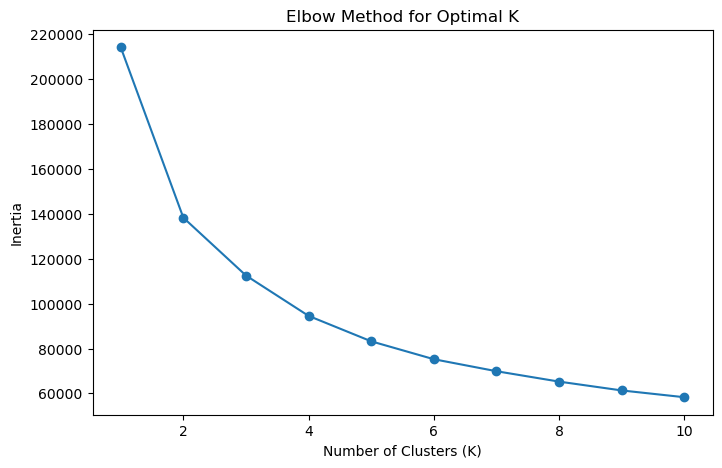

In [23]:
features = df[numerical_features]

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

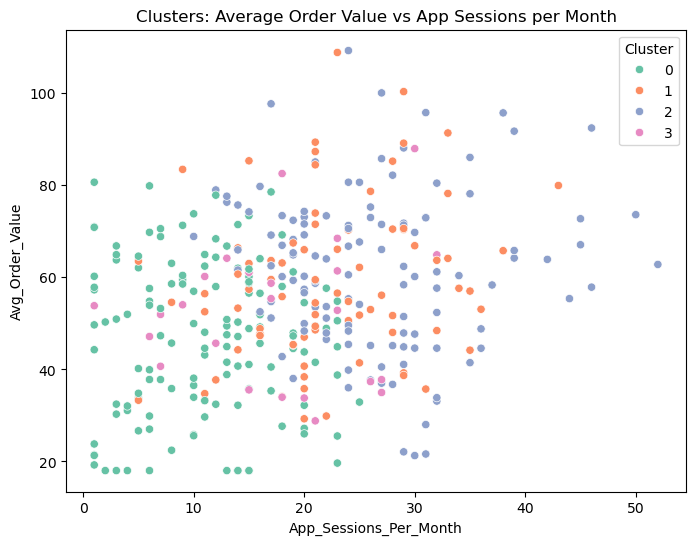

In [24]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_clustered,
                x='App_Sessions_Per_Month',
                y='Avg_Order_Value',
                hue='Cluster',
                palette='Set2')

plt.title("Clusters: Average Order Value vs App Sessions per Month")
plt.show()

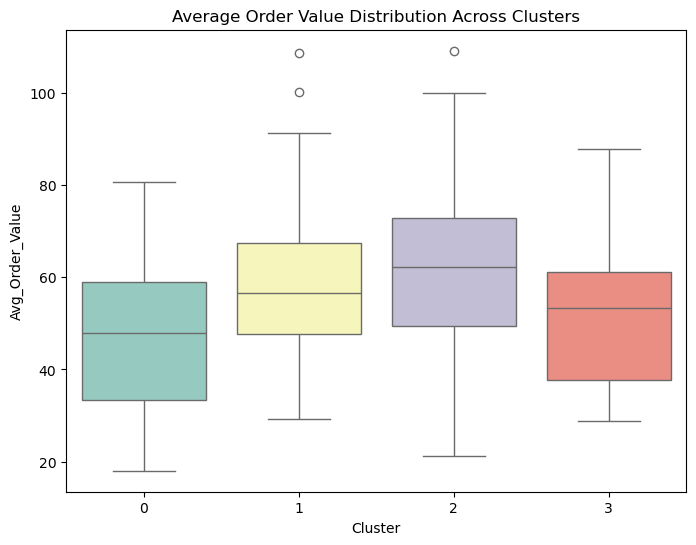

In [25]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_clustered, x='Cluster', y='Avg_Order_Value',
            hue='Cluster', palette='Set3', legend=False)

plt.title("Average Order Value Distribution Across Clusters")
plt.show()

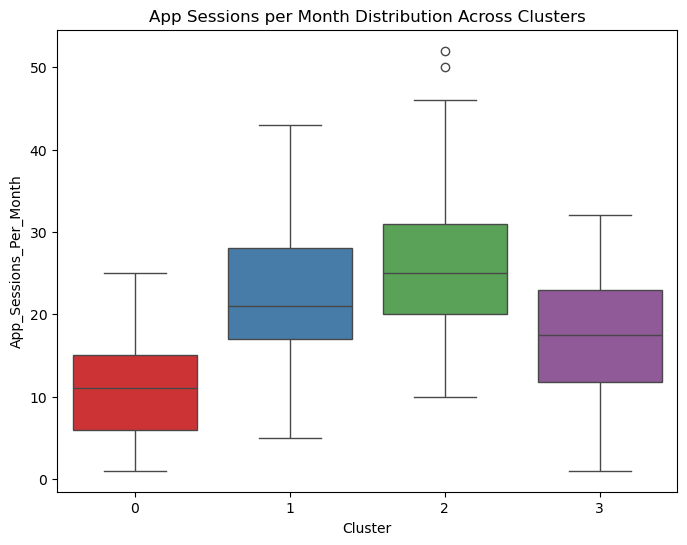

In [26]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_clustered, x='Cluster', y='App_Sessions_Per_Month',
            hue='Cluster', palette='Set1', legend=False)

plt.title("App Sessions per Month Distribution Across Clusters")
plt.show()

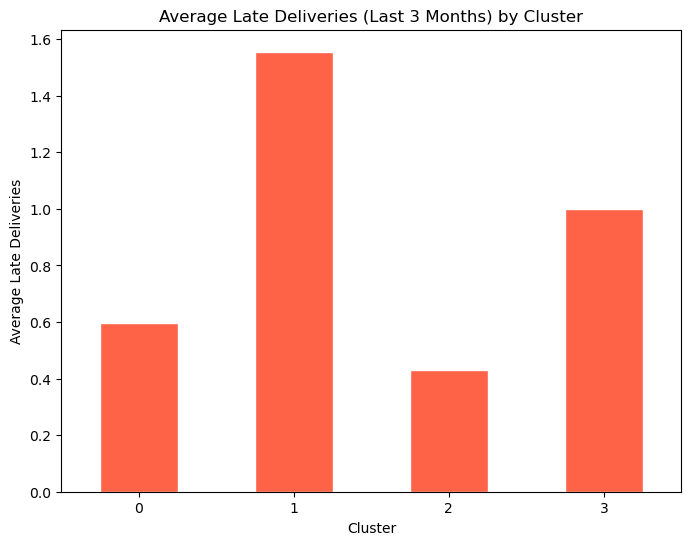

In [27]:
plt.figure(figsize=(8,6))
cluster_late = df_clustered.groupby('Cluster')['Late_Deliveries_Last_3M'].mean()
cluster_late.plot(kind='bar', color='tomato', edgecolor='white')
plt.title("Average Late Deliveries (Last 3 Months) by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Late Deliveries")
plt.xticks(rotation=0)
plt.show()

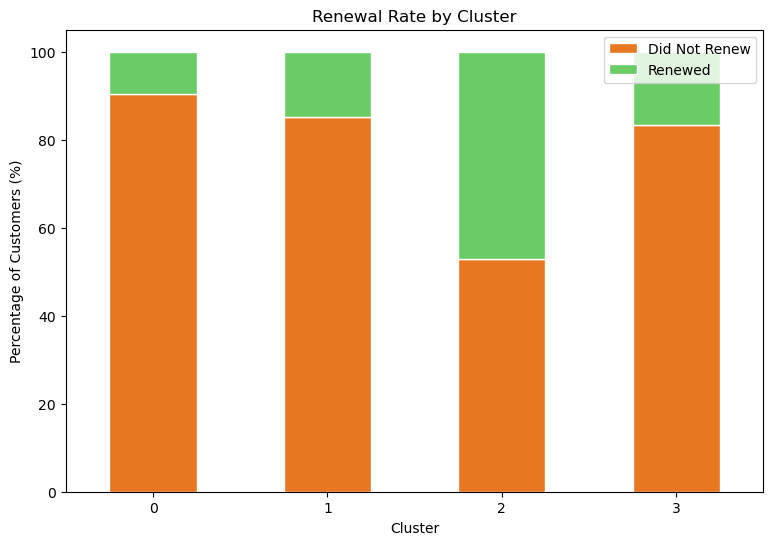

In [28]:
renewal_counts = df_clustered.groupby(['Cluster', 'Renewed_Membership']).size().unstack(fill_value=0)
renewal_pct = renewal_counts.div(renewal_counts.sum(axis=1), axis=0) * 100

renewal_pct.plot(kind='bar', stacked=True, figsize=(9, 6),
                 color=['#E87722', '#6ACC65'], edgecolor='white')
plt.title("Renewal Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Percentage of Customers (%)")
plt.legend(['Did Not Renew', 'Renewed'])
plt.xticks(rotation=0)
plt.show()

In [ ]:
## Limitations and Responsible AI Reflection

### What is one limitation of your dataset or clustering model?

One key limitation of this dataset is that it does not include external context such as household income, local grocery store availability, personal life events (e.g., relocation, change in family size), or regional delivery infrastructure. A customer may cancel their subscription because a competing service launched in their area, or because of a temporary personal hardship — neither of which is captured in the dataset. This means the clustering model may misclassify some customers. For example, a customer in Cluster 0 (Passive Low-Spenders) might simply have a part-time need for the service during certain months rather than being permanently disengaged.

Additionally, K-Means requires features to be numerical, so the categorical columns (Age_Group, City_Type, Membership_Type, Preferred_Category, Competitor_Offer_Seen) were excluded from clustering. Including this context through more advanced methods could produce richer segmentation.

### Why does K-Means not always produce perfect customer segments?

K-Means uses hard assignment — every customer must belong to exactly one cluster with no uncertainty. In reality, customer behaviour exists on a spectrum, and many customers share traits from multiple groups. For example, a customer with high app engagement but occasional late deliveries might belong partly to Cluster 1 (Active At-Risk) and partly to Cluster 2 (High-Value Loyalists). K-Means forces a single assignment. The algorithm also assumes spherical, equally-sized clusters and measures similarity using Euclidean distance, which does not always reflect how customers naturally group in real data. Different random initializations or a different choice of K can also change which customers fall into each cluster.

### What kind of bias or unfair decision could happen if the business uses these clusters without human review?

Several fairness risks arise if clusters are used for automated decisions:

- **Geographic or demographic bias:** If late deliveries disproportionately affect customers in lower-income or rural areas, Cluster 1 may unintentionally group those customers together. Offering them only a discount (rather than fixing the service) would be both unfair and insufficient.
- **Discriminatory service levels:** Cluster 0 customers may receive fewer retention offers than Cluster 2. If Cluster 0 disproportionately represents older customers or those in smaller towns, this could constitute an indirect form of service inequality.
- **Self-fulfilling churn predictions:** If the business stops investing in service improvements for "at-risk" clusters because the model predicts they will leave anyway, the business may cause the very churn it predicted.

### Why should human judgment still be used when making marketing decisions?

Machine learning models, including this K-Means analysis, are tools that support decisions — not tools that replace them. Human judgment is necessary because:

1. **Models do not understand context:** A manager who knows that a regional delivery problem caused temporary late deliveries can distinguish between a one-time event and a systematic service failure. The model cannot.
2. **Fairness must be actively monitored:** Humans need to review whether retention strategies inadvertently treat certain demographic groups differently — something an automated model will not flag on its own.
3. **Customer dignity matters:** Automated decisions about who receives offers or follow-up contact can feel impersonal. Human-mediated outreach ensures customers are treated with respect.
4. **Models can be wrong:** A ~47% renewal rate in Cluster 2 means more than half of those "loyal" customers still did not renew. Treating all Cluster 2 members as certain renewers would miss an opportunity to retain those at the margin.

Business decisions informed by this analysis should always be reviewed, approved, and contextualized by marketing and operations managers before being acted upon.